# 01 — Data Ingestion

**Phase 1 of the Weather → Climate → Wildfire pipeline.**

This notebook is the **single entry point** for loading every raw source the
project depends on, validating it, and writing a clean, analysis-ready copy
to `data/interim/`. All heavy lifting lives in `src/weather/ingestion.py`;
this notebook orchestrates, inspects and reports.

---

## Data sources

| # | Source | File(s) | Purpose |
|---|---|---|---|
| 1 | **Open-Meteo archive** | `data/raw/openmeteo/hourly_weather.csv`, `daily_weather.csv` | Weather history (core) |
| 2 | **WorldPop population** | `data/raw/population/population_YYYY.csv` | Human-activity proxy |
| 3 | **OSM road network** | `data/raw/osm_roads/static_city_infrastructure.csv` | Human-access proxy |
| 4 | **MODIS NDVI (GEE)** | `data/raw/earth_engine/aze_ndvi_2020_2026.csv` | Vegetation dryness |
| 5 | **NASA FIRMS VIIRS** | `data/raw/nasa_firms/viirs-snpp_*.csv` | Historical wildfire labels |
| 6 | **Lightning climatology** | `data/raw/lightning/azerbaijan_lightning_*.csv` | Natural ignition source |
| 7 | **Forest boundaries** | `data/raw/forest_boundaries/azerbaijan.kmz` | Fuel map |
| 8 | **ESA WorldCover** | `data/raw/earth_engine/aze_landcover.tif` | Landcover per city |

## Outputs

Every loader writes to `data/interim/`:

```
weather_hourly_raw.csv      # Core weather — 5 cities × hourly grid
weather_daily_raw.csv       # Daily rain sum
cities_reference.csv        # Name, lat, lon for 16 study cities
population.csv              # Stacked 2020–2026
roads.csv                   # Human-access road density
ndvi.csv                    # Daily NDVI per city
firms.csv                   # Fire hotspots + combined timestamp
lightning.csv               # Grid-month thunder-hours
forest_boundaries.geojson   # (optional) geopandas / fiona required
landcover_at_cities.csv     # (optional) rasterio required
```

## 1. Setup

Make `src/` importable from the notebook and pull in the ingestion helpers.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the project root importable no matter where Jupyter was launched from
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

import pandas as pd
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src.weather import ingestion
from src.utils.config import (
    AZERBAIJAN_CITIES, INTERIM_DIR, RAW_OPENMETEO,
    HOURLY_WEATHER_VARS, FORECAST_TARGETS,
)
from src.utils.logging_utils import get_logger
logger = get_logger("nb.01_ingestion")
logger.info("Setup complete - %d cities in scope", len(AZERBAIJAN_CITIES))

Project root: c:\Users\User\Desktop\ARIAN


00:22:08 | INFO    | nb.01_ingestion | Setup complete - 16 cities in scope


## 2. Weather — Open-Meteo historical archive

The Open-Meteo REST API serves hourly history from 2020-01-01 to the present
for every lat/lon, free of charge. We cached a 2020–2026 snapshot under
`data/raw/openmeteo/` so the notebook runs offline; the same function can
refresh directly from the API when network access is available.

### 2a. Load from disk (default path)

In [2]:
weather_hourly, weather_daily = ingestion.load_weather_from_disk()
weather_hourly.head(3)

00:22:08 | INFO    | src.weather.ingestion | Reading hourly weather  <- C:\Users\User\Desktop\ARIAN\data\raw\openmeteo\hourly_weather.csv
00:22:12 | INFO    | src.weather.ingestion | Reading daily weather   <- C:\Users\User\Desktop\ARIAN\data\raw\openmeteo\daily_weather.csv
00:22:12 | INFO    | src.weather.ingestion | Hourly: 276,000 rows, 5 cities, 2020-01-01 00:00:00+00:00 -> 2026-04-18 23:00:00+00:00
00:22:12 | INFO    | src.weather.ingestion | Daily:  11,500 rows, 5 cities, 2020-01-01 00:00:00+00:00 -> 2026-04-18 00:00:00+00:00


,City,date,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,vapour_pressure_deficit,evapotranspiration,wind_speed_10m,wind_direction_10m,wind_speed_80m,wind_direction_80m,temperature_80m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,is_day,sunshine_duration,shortwave_radiation,direct_radiation
0,Baku,2020-01-01 00:00:00+00:00,5.0,100.0,5.0,0.0,0.0,100.0,100.0,0.0,0.0,0.0,NaN,5.154416,282.09473,NaN,NaN,NaN,10.440001,7.05,9.60,11.3,0.0,0.0,0.0,0.0
1,Baku,2020-01-01 01:00:00+00:00,5.5,100.0,5.5,0.0,0.0,100.0,100.0,0.0,0.0,0.0,NaN,4.693826,212.47118,NaN,NaN,NaN,6.840000,6.50,9.45,11.3,0.0,0.0,0.0,0.0
2,Baku,2020-01-01 02:00:00+00:00,3.6,100.0,3.6,0.0,0.0,80.0,80.0,0.0,0.0,0.0,NaN,9.007196,182.29056,NaN,NaN,NaN,12.240000,6.15,9.25,11.3,0.0,0.0,0.0,0.0


### 2b. Validate structural integrity

`validate_weather_df` reports row counts, city coverage, date range, missing-cell
percentage, and — crucially — whether the hourly / daily cadence has any gaps.

In [3]:
hourly_report = ingestion.validate_weather_df(weather_hourly, kind="hourly")
daily_report  = ingestion.validate_weather_df(weather_daily,  kind="daily")

summary = pd.DataFrame({
    "hourly": {k: v for k, v in hourly_report.items() if k != "timestep_gaps_per_city"},
    "daily":  {k: v for k, v in daily_report.items()  if k != "timestep_gaps_per_city"},
})
summary

,hourly,daily
rows,276000,11500
cities,5,5
date_min,2020-01-01 00:00:00+00:00,2020-01-01 00:00:00+00:00
date_max,2026-04-18 23:00:00+00:00,2026-04-18 00:00:00+00:00
missing_cells,1104000,0
missing_pct,0.166667,0.0


In [4]:
# Gap analysis per city (0 = perfect cadence)
pd.DataFrame({
    "hourly_gaps": hourly_report["timestep_gaps_per_city"],
    "daily_gaps":  daily_report["timestep_gaps_per_city"],
}).fillna(0).astype(int)

,hourly_gaps,daily_gaps
Baku,0,0
Ganja,0,0
Guba,0,0
Lankaran,0,0
Zaqatala,0,0


### 2c. (Optional) Refresh directly from the Open-Meteo API

Uncomment the cell below to re-download. Requires `openmeteo_requests`,
`requests_cache` and `retry_requests`, plus network access.

In [5]:
# hourly_api, daily_api = ingestion.fetch_weather_from_api()
# hourly_api.head()

## 3. Cities reference table

A tiny but important artefact: the canonical mapping from city name to
centroid coordinates, used by every downstream join.

In [6]:
from src.utils.config import cities_as_records
cities_df = pd.DataFrame(cities_as_records())
cities_df

,City,Latitude,Longitude
0,Baku,40.4093,49.8671
1,Ganja,40.6828,46.3606
2,Lankaran,38.7529,48.8515
3,Guba,41.3597,48.5134
4,Zaqatala,41.6336,46.6433
5,Nakhchivan,39.2089,45.4122
6,Sheki,41.1919,47.1706
7,Shirvan,39.9317,48.9290
8,Mingachevir,40.7639,47.0595
9,Khachmaz,41.4635,48.8060


## 4. Auxiliary sources

Each loader is independent and validated in isolation — a failure in one
source never takes down the others.

### 4a. Population (WorldPop, rasterised to city centroids)

In [7]:
population = ingestion.load_population()
population.pivot_table(index="City", columns="Year", values="Pop_Density").round(1)

00:22:13 | INFO    | src.weather.ingestion | Population: 112 rows across years 2020-2026, 16 cities


Year,2020,2021,2022,2023,2024,2025,2026
City,,,,,,,
Baku,69.3,69.7,70.1,70.7,70.5,71.0,71.4
Ganja,74.6,75.0,75.3,75.9,75.7,76.1,76.5
Goychay,25.6,25.7,25.8,26.0,25.9,26.1,26.2
Guba,45.0,45.2,45.5,45.7,45.6,45.8,46.0
Imishli,35.7,35.9,36.1,36.3,36.2,36.4,36.6
Jalilabad,50.0,50.3,50.5,50.9,50.8,51.1,51.4
Khachmaz,38.6,38.8,38.9,39.2,39.1,39.3,39.5
Lankaran,51.2,51.4,51.6,51.9,51.8,52.0,52.2
Mingachevir,53.0,53.3,53.6,53.9,53.8,54.1,54.4


### 4b. Roads (OSM human-access within 5 km of each city)

In [8]:
roads = ingestion.load_roads_static()
roads.sort_values("human_access_road_meters", ascending=False)

00:22:13 | INFO    | src.weather.ingestion | Roads: 16 cities, total 11537 km


,City,human_access_road_meters
1,Ganja,1.663040e+06
0,Baku,1.470499e+06
9,Khachmaz,7.732498e+05
6,Sheki,7.474569e+05
5,Nakhchivan,6.789007e+05
3,Guba,6.767788e+05
11,Shamkir,6.702843e+05
2,Lankaran,6.678211e+05
7,Shirvan,6.599856e+05
10,Goychay,6.122606e+05


### 4c. NDVI (MODIS, per city, Earth Engine export)

In [9]:
ndvi = ingestion.load_ndvi()
print(ndvi.groupby("City")["NDVI"].agg(["min", "mean", "max"]).round(3))
ndvi.head(3)

00:22:13 | INFO    | src.weather.ingestion | NDVI: 2304 rows, 16 cities, 2020-01-01 00:00:00+00:00 -> 2026-03-22 00:00:00+00:00


               min   mean    max
City                            
Baku         0.011  0.200  0.306
Ganja        0.009  0.199  0.339
Goychay      0.056  0.344  0.470
Guba         0.006  0.286  0.507
Imishli      0.137  0.303  0.417
Jalilabad   -0.010  0.359  0.489
Khachmaz     0.042  0.294  0.464
Lankaran    -0.005  0.325  0.584
Mingachevir  0.011  0.325  0.505
Nakhchivan   0.008  0.179  0.278
Sabirabad    0.076  0.307  0.488
Shamakhi     0.005  0.338  0.565
Shamkir      0.006  0.288  0.446
Sheki        0.005  0.301  0.484
Shirvan      0.043  0.259  0.384
Zaqatala     0.002  0.353  0.528


,City,date,NDVI
0,Baku,2020-01-01 00:00:00+00:00,0.1624
1,Baku,2020-01-17 00:00:00+00:00,0.1926
2,Baku,2020-02-02 00:00:00+00:00,0.1294


### 4d. NASA FIRMS (VIIRS wildfire hotspots)

In [10]:
firms = ingestion.load_firms()
print("Annual fire counts:")
print(firms["acq_date"].dt.year.value_counts().sort_index())
firms[["latitude", "longitude", "acq_timestamp", "bright_ti4", "frp", "confidence", "daynight"]].head(3)

00:22:13 | INFO    | src.weather.ingestion | FIRMS: 21218 hotspots, 2020-01-01 00:00:00 -> 2024-12-31 00:00:00


Annual fire counts:
acq_date
2020    5196
2021    5667
2022    4814
2023    2842
2024    2699
Name: count, dtype: int64


,latitude,longitude,acq_timestamp,bright_ti4,frp,confidence,daynight
0,40.19473,49.46200,2020-01-01 10:23:00+00:00,338.08,4.21,n,D
1,40.19724,49.46228,2020-01-01 10:23:00+00:00,344.28,3.65,n,D
2,41.16796,45.25504,2020-01-01 22:42:00+00:00,296.02,0.72,n,N


### 4e. Lightning (climatology grid)

In [11]:
lightning = ingestion.load_lightning()
print("Thunder-hours per month (all years pooled):")
print(lightning.groupby("month")["thunder_hours"].sum())
lightning.head(3)

00:22:13 | INFO    | src.weather.ingestion | Lightning: 366619 grid-month obs over 6 years


Thunder-hours per month (all years pooled):
month
1       3435
2       4309
3      35622
4     191125
5     463019
6     372981
7     199579
8     207453
9     190264
10    132314
11     14477
12      6388
Name: thunder_hours, dtype: int64


,lat,lon,month,thunder_hours,year
0,38.025,50.525,1,1,2020
1,38.025,50.575,1,2,2020
2,38.025,50.625,1,2,2020


### 4f. Forest boundaries and landcover (require `geopandas` / `rasterio`)

These cells skip themselves with a clear message if the optional geo libraries
are missing — the pipeline still produces complete tabular outputs.

In [12]:
try:
    forests = ingestion.load_forest_boundaries()
    print(f"Forests: {len(forests)} polygons, CRS={forests.crs}")
    forests.head(3)
except RuntimeError as exc:
    print(f"[skipped] {exc}")
    forests = None
forests

00:22:18 | INFO    | src.weather.ingestion | Forests: 4 features from doc.kml


Forests: 4 polygons, CRS=EPSG:4326


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,ha,geometry
0,0,None,None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,2302.37,"MULTIPOLYGON Z (((46.77893 40.09749 0, 46.7788..."
1,0,None,None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,4822.38,"MULTIPOLYGON Z (((46.42709 40.15505 0, 46.4271..."
2,0,None,None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,923302.00,"MULTIPOLYGON Z (((48.64034 38.48963 0, 48.6402..."
3,0,None,None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,1520.72,"MULTIPOLYGON Z (((45.82352 39.01123 0, 45.8234..."


In [13]:
try:
    landcover = ingestion.sample_landcover_at_cities()
    display(landcover)
except RuntimeError as exc:
    print(f"[skipped] {exc}")
    landcover = None

00:22:27 | INFO    | src.weather.ingestion | Landcover: 16 cities sampled, classes = [0, 10, 20, 50]


,City,Landcover_Class
0,Baku,50
1,Ganja,50
2,Lankaran,50
3,Guba,10
4,Zaqatala,0
5,Nakhchivan,50
6,Sheki,50
7,Shirvan,20
8,Mingachevir,10
9,Khachmaz,10


## 5. Run the full pipeline & persist interim outputs

The orchestrator calls every loader, catches per-source failures and writes
clean copies to `data/interim/`. Use `fmt='parquet'` in production (much
smaller, typed); CSV is the portable default.

In [14]:
outputs = ingestion.run_ingestion_pipeline(use_api=False, fmt="csv", include_geo=True)

summary_rows = []
for name, df in outputs.items():
    summary_rows.append({"dataset": name, "rows": len(df), "cols": df.shape[1] if hasattr(df, 'shape') else None})
pd.DataFrame(summary_rows)

00:22:28 | INFO    | src.weather.ingestion | ========================================================================
00:22:28 | INFO    | src.weather.ingestion | PHASE 1 - Data Ingestion pipeline starting
00:22:28 | INFO    | src.weather.ingestion | ========================================================================
00:22:28 | INFO    | src.weather.ingestion | Reading hourly weather  <- C:\Users\User\Desktop\ARIAN\data\raw\openmeteo\hourly_weather.csv
00:22:29 | INFO    | src.weather.ingestion | Reading daily weather   <- C:\Users\User\Desktop\ARIAN\data\raw\openmeteo\daily_weather.csv
00:22:30 | INFO    | src.weather.ingestion | Hourly: 276,000 rows, 5 cities, 2020-01-01 00:00:00+00:00 -> 2026-04-18 23:00:00+00:00
00:22:30 | INFO    | src.weather.ingestion | Daily:  11,500 rows, 5 cities, 2020-01-01 00:00:00+00:00 -> 2026-04-18 00:00:00+00:00
00:22:36 | INFO    | src.weather.ingestion | Saved 276,000 rows -> C:\Users\User\Desktop\ARIAN\data\interim\weather_hourly_raw.csv (42.00 

,dataset,rows,cols
0,weather_hourly,276000,26
1,weather_daily,11500,3
2,cities,16,3
3,population,112,5
4,roads,16,2
5,ndvi,2304,3
6,firms,21218,16
7,lightning,366619,5
8,forests,4,14
9,landcover,16,2


In [15]:
# Inventory of interim/ — everything downstream Phase 2 will consume
from pathlib import Path
interim = sorted(INTERIM_DIR.glob("*"))
pd.DataFrame({
    "file": [p.name for p in interim],
    "size_MB": [round(p.stat().st_size / 1024 / 1024, 3) for p in interim],
})

,file,size_MB
0,cities_reference.csv,0.000
1,firms.csv,2.125
2,forest_boundaries.geojson,124.337
3,landcover_at_cities.csv,0.000
4,lightning.csv,8.487
5,multi_horizon_summary.csv,0.004
6,ndvi.csv,0.093
7,population.csv,0.005
8,roads.csv,0.000
9,summary.csv,0.002


## 6. Quick visual QC

A first sanity check that the hourly weather pulled from Open-Meteo looks
physically reasonable — temperature should show a clean annual cycle, and
the cities should all share the same envelope with local shifts.

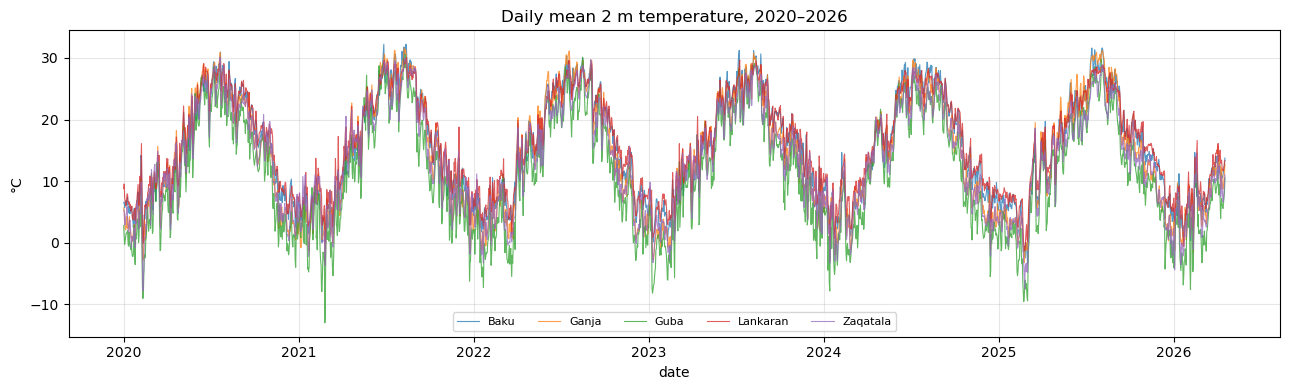

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
for city, g in weather_hourly.groupby("City"):
    # Daily mean for legibility across ~55k hours
    daily = g.set_index("date")["temperature_2m"].resample("D").mean()
    ax.plot(daily.index, daily.values, label=city, lw=0.8, alpha=0.75)

ax.set_title("Daily mean 2 m temperature, 2020–2026")
ax.set_ylabel("°C"); ax.set_xlabel("date")
ax.legend(ncol=5, fontsize=8, loc="lower center")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# Missingness map per variable and per city — shows if any source station dropped a column
miss = (
    weather_hourly
    .drop(columns=["date"])
    .groupby("City")
    .apply(lambda g: g.isna().mean().round(3), include_groups=False)
)
miss.style.background_gradient(cmap="Reds", vmin=0, vmax=0.2) if hasattr(miss, "style") else miss

,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,vapour_pressure_deficit,evapotranspiration,wind_speed_10m,wind_direction_10m,wind_speed_80m,wind_direction_80m,temperature_80m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,is_day,sunshine_duration,shortwave_radiation,direct_radiation
City,,,,,,,,,,,,,,,,,,,,,,,,
Baku,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ganja,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Guba,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Lankaran,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Zaqatala,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 7. Hand-off to Phase 2

Everything Phase 2 (weather cleaning + modelling) needs is now in
`data/interim/`:

1. **`weather_hourly_raw.csv`** — the core forecasting dataset
2. **`weather_daily_raw.csv`** — daily rain-sum reference
3. **`cities_reference.csv`** — 16 study locations
4. **Auxiliary frames** — population, roads, ndvi, firms, lightning
   (the wildfire system in Phase 4 will consume these)

Forecast targets (per `src.utils.config.FORECAST_TARGETS`):

In [18]:
print("Forecast targets:", FORECAST_TARGETS)
print("\nTargets available in weather_hourly:",
      [t for t in FORECAST_TARGETS if t in weather_hourly.columns])
missing = [t for t in FORECAST_TARGETS if t not in weather_hourly.columns]
print("Missing:", missing or "(none)")

Forecast targets: ['temperature_2m', 'wind_speed_10m', 'wind_direction_10m', 'rain', 'precipitation']

Targets available in weather_hourly: ['temperature_2m', 'wind_speed_10m', 'wind_direction_10m', 'rain', 'precipitation']
Missing: (none)


---
**Phase 1 ✅ complete.** Move to `02_weather_cleaning.ipynb`.